In [2]:
pip install pandas matplotlib numpy wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\raich\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [31]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

In [35]:
import os

BASE_DIR = os.path.abspath("..")   # Go one level up from notebooks
OUTPUT = os.path.join(BASE_DIR, "output")

os.makedirs(OUTPUT, exist_ok=True)

knowledge = pd.read_csv(
    os.path.join(PROCESSED, "knowledge_base.csv")
)

In [36]:
knowledge = pd.read_csv(
    os.path.join(
        PROCESSED,
        "knowledge_base.csv"
    )
)

print("Dataset Loaded Successfully")

knowledge.head()

Dataset Loaded Successfully


,prompt,context,response,source_dataset
0,What is (are) Monkeypox Virus Infections ?,NaN,Monkeypox is a rare viral disease. It occurs m...,MedQuAD
1,Do you have information about Vitamin K,NaN,Summary : Vitamins are substances that your bo...,MedQuAD
2,What is (are) phosphoribosylpyrophosphate synt...,NaN,Phosphoribosylpyrophosphate synthetase superac...,MedQuAD
3,What are the symptoms of Kallmann syndrome 6 ?,NaN,What are the signs and symptoms of Kallmann sy...,MedQuAD
4,Is Marfan syndrome inherited ?,NaN,How is Marfan syndrome inherited? Marfan syndr...,MedQuAD


In [37]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)

print("Shape :", knowledge.shape)

print("\nColumns\n")

for col in knowledge.columns:
    print(col)

print("\n")

knowledge.info()

DATASET OVERVIEW
Shape : (15979, 4)

Columns

prompt
context
response
source_dataset


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15979 entries, 0 to 15978
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   prompt          15979 non-null  object
 1   context         1000 non-null   object
 2   response        15979 non-null  object
 3   source_dataset  15979 non-null  object
dtypes: object(4)
memory usage: 499.5+ KB


In [38]:
with open(
    os.path.join(OUTPUT, "dataset_overview.txt"),
    "w",
    encoding="utf-8"
) as f:

    f.write("=" * 70 + "\n")
    f.write("KNOWLEDGE BASE OVERVIEW\n")
    f.write("=" * 70 + "\n\n")

    f.write(f"Shape : {knowledge.shape}\n\n")

    f.write("Columns\n")
    for col in knowledge.columns:
        f.write(col + "\n")

    f.write("\n")
    f.write(str(knowledge.dtypes))

print("dataset_overview.txt saved.")

dataset_overview.txt saved.


In [39]:
missing = knowledge.isnull().sum()

missing

prompt                0
context           14979
response              0
source_dataset        0
dtype: int64

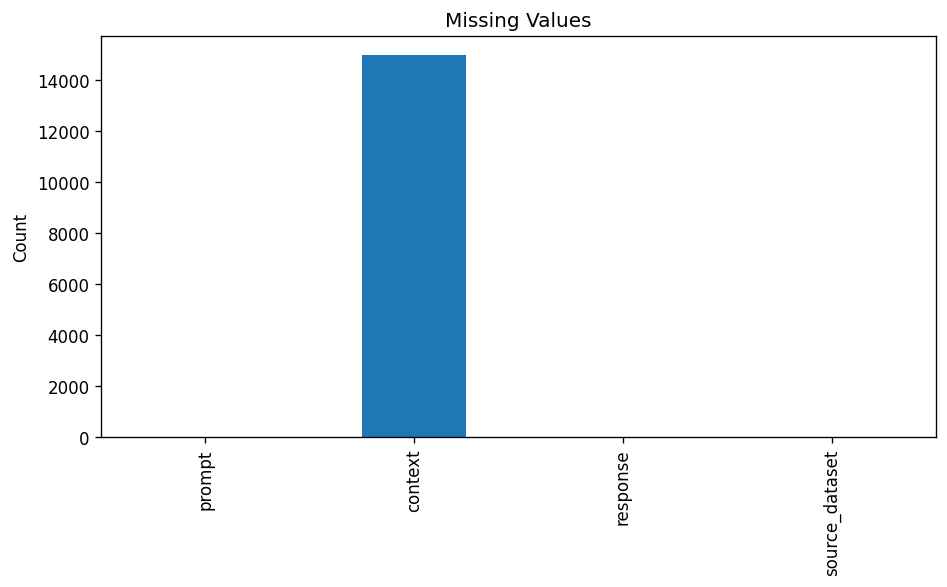

In [40]:
plt.figure(figsize=(8,5))

missing.plot(kind="bar")

plt.title("Missing Values")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT,
        "missing_values.png"
    ),
    dpi=300
)

plt.show()

In [41]:
duplicate_rows = knowledge.duplicated().sum()

duplicate_prompts = knowledge["prompt"].duplicated().sum()

duplicate_responses = knowledge["response"].duplicated().sum()

duplicates = pd.DataFrame({

    "Metric":[

        "Duplicate Rows",

        "Duplicate Prompts",

        "Duplicate Responses"

    ],

    "Count":[

        duplicate_rows,

        duplicate_prompts,

        duplicate_responses

    ]

})

duplicates

,Metric,Count
0,Duplicate Rows,0
1,Duplicate Prompts,0
2,Duplicate Responses,518


In [42]:
duplicates.to_csv(

    os.path.join(

        OUTPUT,

        "duplicate_statistics.csv"

    ),

    index=False

)

In [43]:
source = knowledge["source_dataset"].value_counts()

source

source_dataset
MedQuAD     14979
PubMedQA     1000
Name: count, dtype: int64

In [44]:
source.to_csv(

    os.path.join(

        OUTPUT,

        "source_distribution.csv"

    )

)

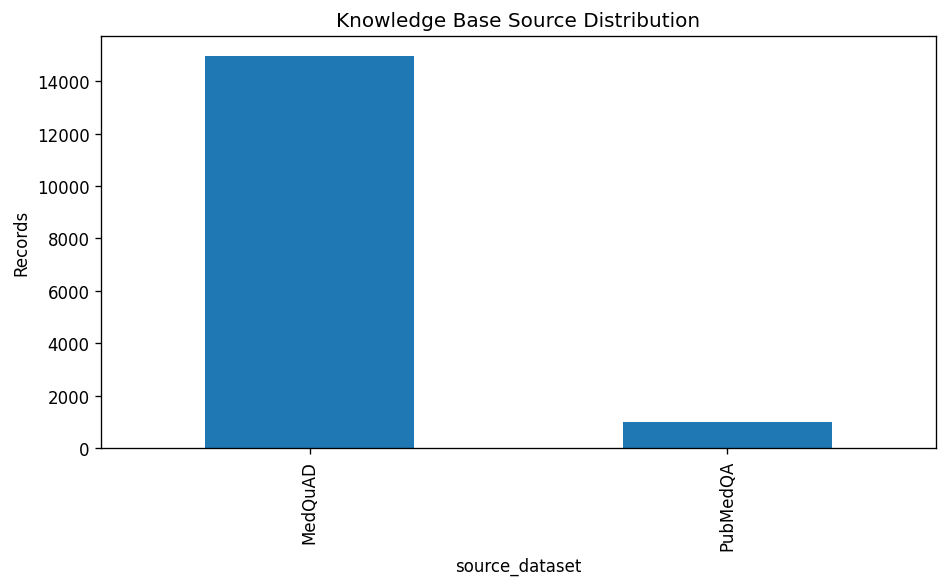

In [45]:
plt.figure(figsize=(8,5))

source.plot(

    kind="bar"

)

plt.title(

    "Knowledge Base Source Distribution"

)

plt.ylabel("Records")

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUT,

        "source_distribution.png"

    ),

    dpi=300

)

plt.show()

In [46]:
knowledge["prompt_characters"] = (

    knowledge["prompt"]

    .fillna("")

    .str.len()

)

knowledge["prompt_words"] = (

    knowledge["prompt"]

    .fillna("")

    .str.split()

    .str.len()

)

knowledge[

    [

        "prompt_characters",

        "prompt_words"

    ]

].describe()

,prompt_characters,prompt_words
count,15979.000000,15979.000000
mean,54.295513,8.575756
std,20.583102,2.737379
min,16.000000,3.000000
25%,40.000000,7.000000
50%,51.000000,8.000000
75%,64.000000,10.000000
max,213.000000,31.000000


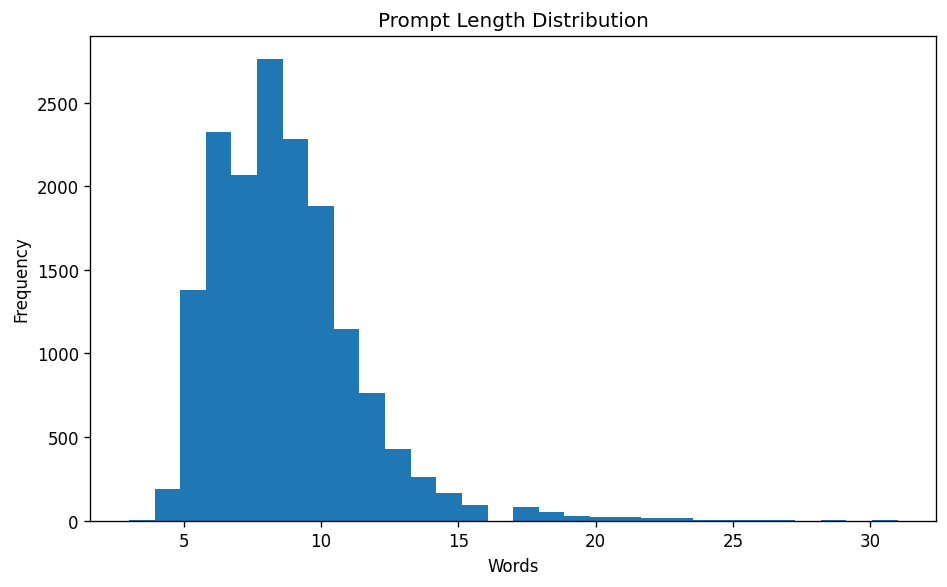

In [47]:
plt.figure(figsize=(8,5))

plt.hist(

    knowledge["prompt_words"],

    bins=30

)

plt.title(

    "Prompt Length Distribution"

)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUT,

        "prompt_length_histogram.png"

    ),

    dpi=300

)

plt.show()

In [48]:
knowledge["response_characters"] = (

    knowledge["response"]

    .fillna("")

    .str.len()

)

knowledge["response_words"] = (

    knowledge["response"]

    .fillna("")

    .str.split()

    .str.len()

)

knowledge[

    [

        "response_characters",

        "response_words"

    ]

].describe()

,response_characters,response_words
count,15979.000000,15979.000000
mean,1223.248639,188.728769
std,1621.110694,243.238080
min,6.000000,1.000000
25%,422.000000,61.000000
50%,818.000000,127.000000
75%,1526.000000,245.000000
max,29046.000000,4281.000000


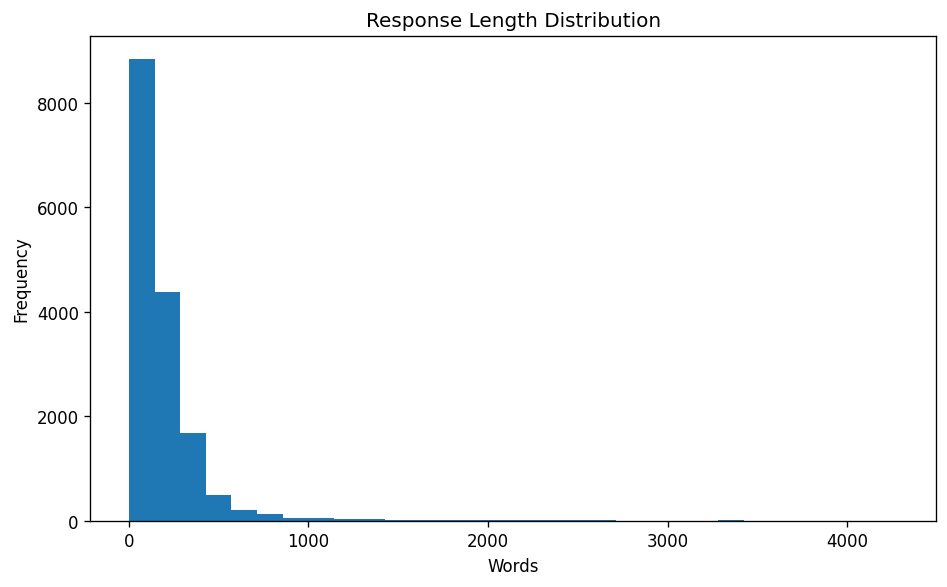

In [49]:
plt.figure(figsize=(8,5))

plt.hist(

    knowledge["response_words"],

    bins=30

)

plt.title(

    "Response Length Distribution"

)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUT,

        "response_length_histogram.png"

    ),

    dpi=300

)

plt.show()

In [51]:
knowledge["context_characters"] = (

    knowledge["context"]

    .fillna("")

    .str.len()

)

knowledge["context_words"] = (

    knowledge["context"]

    .fillna("")

    .str.split()

    .str.len()

)

knowledge[

    [

        "context_characters",

        "context_words"

    ]

].describe()

,context_characters,context_words
count,15979.000000,15979.000000
mean,83.939170,12.529382
std,336.111889,50.196595
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,2725.000000,398.000000


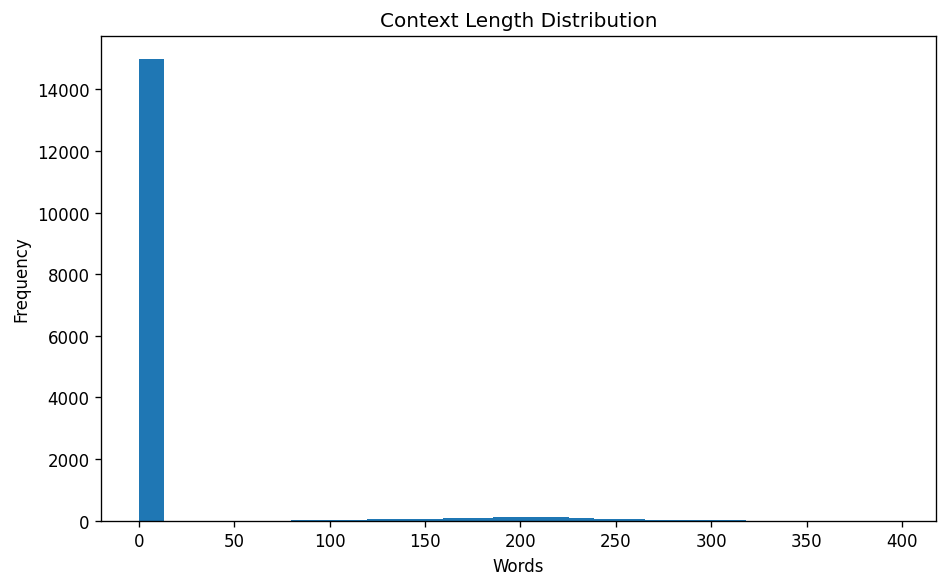

In [52]:
plt.figure(figsize=(8,5))

plt.hist(

    knowledge["context_words"],

    bins=30

)

plt.title(

    "Context Length Distribution"

)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUT,

        "context_length_histogram.png"

    ),

    dpi=300

)

plt.show()

In [53]:
statistics = knowledge.describe(include="all")

statistics.to_csv(

    os.path.join(

        OUTPUT,

        "knowledge_statistics.csv"

    )

)

print("Statistics Saved Successfully.")

Statistics Saved Successfully.
